In [1]:
print("dd")

dd


# 05 – Correlation and Multicollinearity Analysis

## Objective
- Redundant information
- Multicollinearity risks
- Feature groups that capture similar signals


In [2]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

conn = sqlite3.connect("instacart.db")


## Construct Numeric Feature Dataset

To analyze correlations, we first construct a compact dataset
containing the core numerical features identified during EDA.


In [3]:
features_df = pd.read_sql("""
SELECT
    o.user_id,
    opp.product_id,
    COUNT(*) AS times_bought,
    SUM(opp.reordered) AS times_reordered,
    AVG(opp.reordered) AS user_product_reorder_ratio,
    COUNT(DISTINCT o.order_id) AS user_total_orders
FROM order_products_prior opp
JOIN orders o
    ON opp.order_id = o.order_id
GROUP BY o.user_id, opp.product_id
""", conn)

features_df.head()


,user_id,product_id,times_bought,times_reordered,user_product_reorder_ratio,user_total_orders
0,1,196,10,9,0.900000,10
1,1,10258,9,8,0.888889,9
2,1,10326,1,0,0.000000,1
3,1,12427,10,9,0.900000,10
4,1,13032,3,2,0.666667,3


In [5]:
numeric_features = features_df[
    ["times_bought", "times_reordered", "user_product_reorder_ratio", "user_total_orders"]
]

## Correlation Matrix

We compute pairwise correlations to identify strongly related features.
High correlations may indicate redundancy.


In [6]:
corr_matrix = numeric_features.corr()
corr_matrix

,times_bought,times_reordered,user_product_reorder_ratio,user_total_orders
times_bought,1.000000,1.000000,0.654283,1.000000
times_reordered,1.000000,1.000000,0.654283,1.000000
user_product_reorder_ratio,0.654283,0.654283,1.000000,0.654283
user_total_orders,1.000000,1.000000,0.654283,1.000000


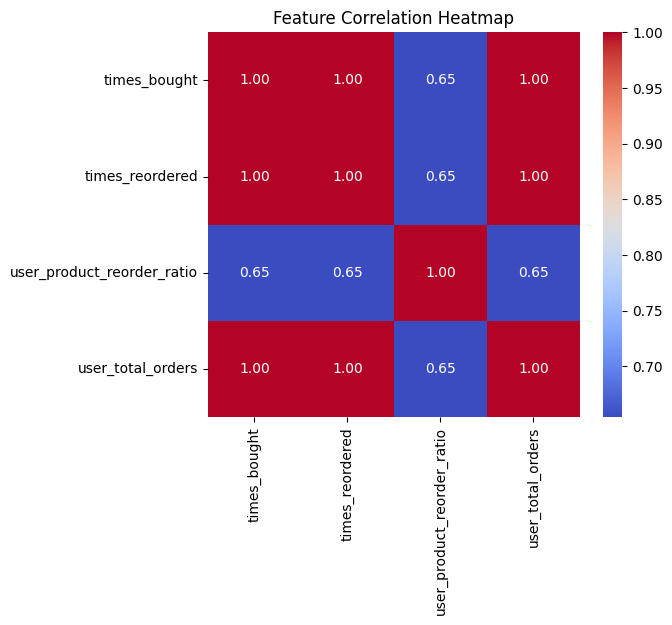

In [7]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()


### Interpretation of Feature Correlation Heatmap

- **times_bought**, **times_reordered**, and **user_total_orders** are almost perfectly correlated (correlation ≈ 1.00).
  - This is expected because these features are all driven by **interaction frequency**.
  - As users place more orders, both purchase counts and reorder counts naturally increase.

- **user_product_reorder_ratio** shows a **moderate correlation (~0.65)** with the count-based features.
  - This indicates that the ratio captures **relative behavior** rather than absolute frequency.
  - It provides complementary information not fully explained by raw counts.

#### Interpretation

The presence of very high correlations among count-based features indicates **strong multicollinearity**.
However, this multicollinearity is **structural**, not accidental:
- These features measure different views of the same underlying behavior (purchase volume).

The reorder ratio behaves differently and reflects **habit consistency**, making it a valuable feature
despite moderate correlation with counts.
